# Detection Evaluation Analysis
Analyse des prédictions du VLM sur le dataset de 490 mèmes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Chargement des données

In [2]:
CSV_PATH = '../../report/detection_predictions.csv'

df = pd.read_csv(CSV_PATH)
print(f'Total rows: {len(df)}')
df.head()

Total rows: 490


,id,img,label_true,text,prob_pred,label_pred,classification,description,modality_type,error
0,57823,img/57823.png,0,"bitches be like no weave, no makeup, no lashes...",0.95,1,hateful,The meme uses the racial slur 'bitches' as a b...,NaN,NaN
1,80947,img/80947.png,1,my new muslim girlfriend not much to look at,0.95,1,hateful,The meme uses a large black covering to repres...,NaN,NaN
2,30145,img/30145.png,0,"before my presidency, there was no isis. there...",0.05,0,non-hateful,The meme uses the 'I built that' format to sar...,NaN,NaN
3,80243,img/80243.png,1,mississippi wind chime,0.99,1,hateful,"The image depicts a historical lynching scene,...",NaN,NaN
4,3217,img/03217.png,0,"they are like sperm you get millions, but only...",0.99,1,non-hateful,The meme compares 'ideas' to sperm in terms of...,NaN,NaN


In [3]:
# Séparer les lignes valides des erreurs
errors = df[df['error'].notna() & (df['error'] != '')]
df = df[df['prob_pred'].notna() & (df['error'].isna() | (df['error'] == ''))].copy()
df['prob_pred']  = df['prob_pred'].astype(float)
df['label_pred'] = df['label_pred'].astype(int)
df['label_true'] = df['label_true'].astype(int)

print(f'Images valides  : {len(df)}')
print(f'Erreurs skippées: {len(errors)}')
print(f"Label=1 (hateful)    : {df['label_true'].sum()}")
print(f"Label=0 (non-hateful): {(df['label_true']==0).sum()}")

Images valides  : 490
Erreurs skippées: 0
Label=1 (hateful)    : 245
Label=0 (non-hateful): 245


## 2. Métriques globales

In [4]:
y_true = df['label_true'].values
y_prob = df['prob_pred'].values
y_pred = df['label_pred'].values

auroc    = roc_auc_score(y_true, y_prob)
macro_f1 = f1_score(y_true, y_pred, average='macro')
acc      = accuracy_score(y_true, y_pred)

metrics = pd.DataFrame({
    'Metric': ['AUROC', 'Macro-F1', 'Accuracy'],
    'Value':  [auroc,   macro_f1,   acc]
})
metrics['Value'] = metrics['Value'].round(4)
metrics

,Metric,Value
0,AUROC,0.6814
1,Macro-F1,0.6102
2,Accuracy,0.6184


In [5]:
print(classification_report(y_true, y_pred, target_names=['non-hateful', 'hateful'], digits=4))

              precision    recall  f1-score   support

 non-hateful     0.6667    0.4735    0.5537       245
     hateful     0.5918    0.7633    0.6667       245

    accuracy                         0.6184       490
   macro avg     0.6292    0.6184    0.6102       490
weighted avg     0.6292    0.6184    0.6102       490



## 3. Matrice de confusion

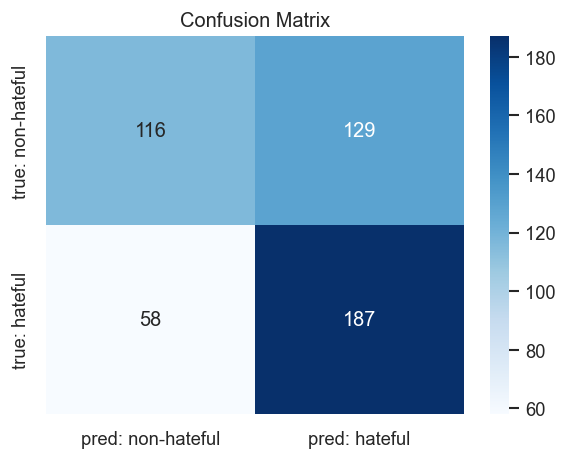

True Positives  (TP): 187  — hateful détectés correctement
True Negatives  (TN): 116  — non-hateful détectés correctement
False Positives (FP): 129  — non-hateful classés hateful à tort
False Negatives (FN): 58  — hateful manqués


In [6]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['pred: non-hateful', 'pred: hateful'],
    yticklabels=['true: non-hateful', 'true: hateful'],
    ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (TP): {tp}  — hateful détectés correctement')
print(f'True Negatives  (TN): {tn}  — non-hateful détectés correctement')
print(f'False Positives (FP): {fp}  — non-hateful classés hateful à tort')
print(f'False Negatives (FN): {fn}  — hateful manqués')

## 4. Distribution des probabilités prédites

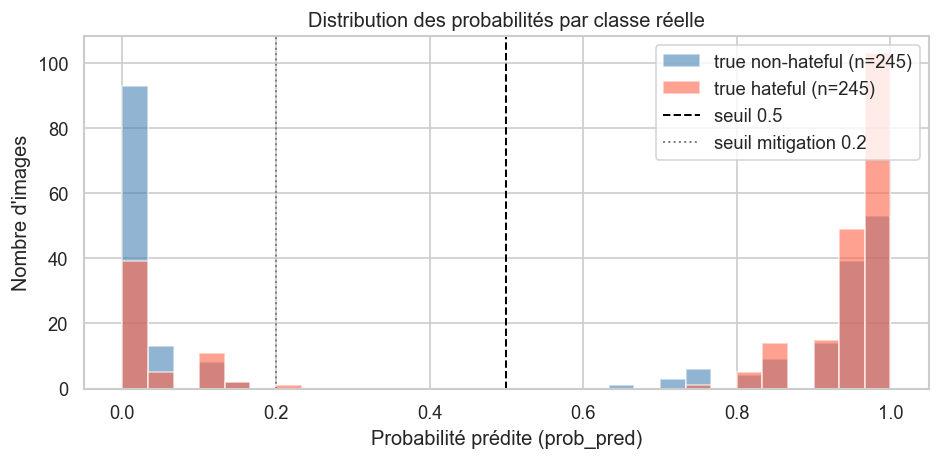

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, color, name in [(0, 'steelblue', 'non-hateful'), (1, 'tomato', 'hateful')]:
    subset = df[df['label_true'] == label]['prob_pred']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'true {name} (n={len(subset)})')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='seuil 0.5')
ax.axvline(0.2, color='gray',  linestyle=':',  linewidth=1.2, label='seuil mitigation 0.2')
ax.set_xlabel('Probabilité prédite (prob_pred)')
ax.set_ylabel('Nombre d\'images')
ax.set_title('Distribution des probabilités par classe réelle')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Courbe ROC

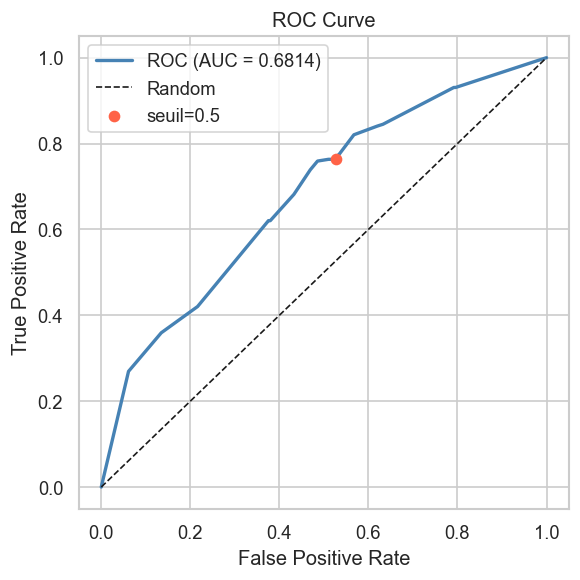

In [8]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auroc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

# Marquer le seuil 0.5
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], color='tomato', zorder=5, label='seuil=0.5')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sensibilité au seuil de décision

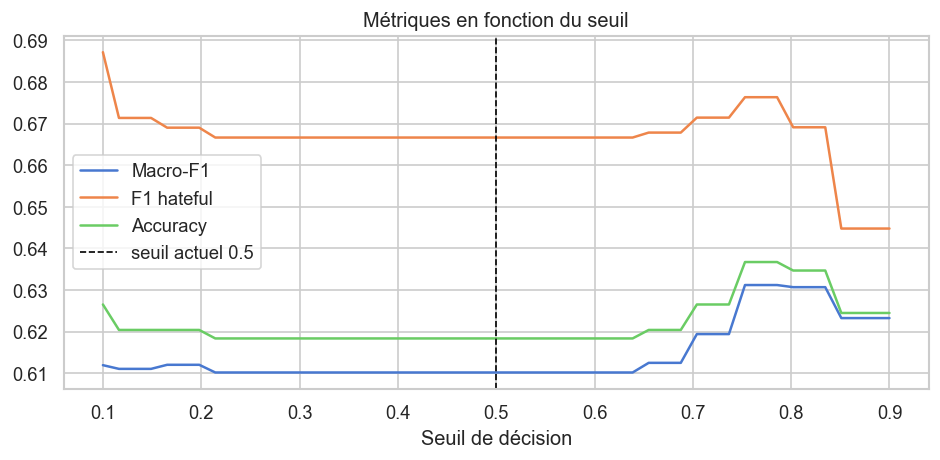

Meilleur seuil pour Macro-F1 : 0.75  →  F1=0.6312


In [9]:
thres_range = np.linspace(0.1, 0.9, 50)
results = []
for t in thres_range:
    y_t = (y_prob >= t).astype(int)
    results.append({
        'threshold': t,
        'macro_f1':  f1_score(y_true, y_t, average='macro', zero_division=0),
        'f1_hateful': f1_score(y_true, y_t, pos_label=1, zero_division=0),
        'accuracy':  accuracy_score(y_true, y_t),
    })
res = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res['threshold'], res['macro_f1'],    label='Macro-F1')
ax.plot(res['threshold'], res['f1_hateful'],  label='F1 hateful')
ax.plot(res['threshold'], res['accuracy'],    label='Accuracy')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='seuil actuel 0.5')
ax.set_xlabel('Seuil de décision')
ax.set_title('Métriques en fonction du seuil')
ax.legend()
plt.tight_layout()
plt.show()

best = res.loc[res['macro_f1'].idxmax()]
print(f"Meilleur seuil pour Macro-F1 : {best['threshold']:.2f}  →  F1={best['macro_f1']:.4f}")

## 7. Analyse des erreurs

In [10]:
# Faux positifs — non-hateful classés hateful
fp_df = df[(df['label_true'] == 0) & (df['label_pred'] == 1)].sort_values('prob_pred', ascending=False)
print(f'Faux positifs : {len(fp_df)}')
fp_df[['id', 'prob_pred', 'text', 'description']].head(10)

Faux positifs : 129


,id,prob_pred,text,description
273,16850,1.0,okay okay okay here's my serious face do i loo...,The meme features a photograph of Adolf Hitler...
371,1268,1.0,father and daughter bonding time is the best l...,The meme depicts a heartwarming scene of a fat...
248,73526,1.0,"if she's still making noises, you didn't hit h...",The text promotes physical violence against wo...
291,38047,1.0,"""stupid bitch"" is not a race",The meme uses a racial slur and targets the id...
306,87251,1.0,i love apes they are both ugly and cute,The meme explicitly equates a Black child with...
115,46087,1.0,give that man a suicide,The meme text 'give that man a suicide' consti...
341,8451,1.0,when you ask a jewish girl for her number and ...,The meme utilizes a historical photograph of e...
347,34209,1.0,how about a nice 12 yr old? bartender: him: bo...,The meme depicts a priest inappropriately agre...
42,19385,1.0,rose's are red violet's are blue little stupid...,The meme features the text 'little stupid ass ...
121,63921,1.0,taking a photo with family,The image displays a diverse group of people s...


In [11]:
# Faux négatifs — hateful manqués
fn_df = df[(df['label_true'] == 1) & (df['label_pred'] == 0)].sort_values('prob_pred')
print(f'Faux négatifs : {len(fn_df)}')
fn_df[['id', 'prob_pred', 'text', 'description']].head(10)

Faux négatifs : 58


,id,prob_pred,text,description
431,34528,0.0,every kitchen needs a sandwich maker just like...,The meme is a commercial advertisement for a s...
365,1796,0.0,life hack #23 how to get stoned with no weed,"The image shows two people, one kissing the ot..."
193,72168,0.0,upper downer,The meme juxtaposes an image of a white powder...
175,30148,0.0,you mean i don't have to pick it?!?,The meme features a child eating cotton candy ...
472,85761,0.0,no wonder why the pipes are not working,The image shows a pipe on a beach with a sign ...
161,6123,0.0,a group of men,"The meme features a picture of dogs, which are..."
245,82301,0.0,cooooooooooooon!!!!,The image depicts a dog howling in a snowy lan...
134,39607,0.0,those stupid basterds thought it was a real sh...,"The meme depicts Adolf Hitler, a historical fi..."
132,79085,0.0,today we are making vegetable soup,"The image shows two people cooking soup, with ..."
131,35840,0.0,i ordered a dishwasher and they sent me a sand...,The meme depicts a woman in a moving box expre...


In [12]:
# Cas les plus incertains (prob proche de 0.5)
df['uncertainty'] = (df['prob_pred'] - 0.5).abs()
uncertain = df.nsmallest(10, 'uncertainty')
print('Prédictions les plus incertaines (prob ≈ 0.5):')
uncertain[['id', 'label_true', 'prob_pred', 'label_pred', 'text']].reset_index(drop=True)

Prédictions les plus incertaines (prob ≈ 0.5):


,id,label_true,prob_pred,label_pred,text
0,49621,0,0.65,1,"wait, mohammad come back i didn't mean to laug..."
1,41728,0,0.70,1,i believe they are like racism. just shouldn't...
2,35497,0,0.70,1,old people at weddings always poke me and say ...
3,5213,0,0.70,1,the families of the hillsborough tragedy were ...
4,14865,0,0.75,1,"terrible as hitler was, he did enjoy watching ..."
5,76015,0,0.75,1,everyone celebrates christmas !
6,29437,1,0.75,1,what can happen if you eat wheaties for 38 years
7,82945,0,0.75,1,be careful who you call ugly in highschool
8,46812,0,0.75,1,goat meat is very popular in islamic countries
9,47103,0,0.75,1,maybe we weren't consistent sources of crime w...


## 8. Analyse par modalité (si disponible)

In [13]:
mod_df = df[df['modality_type'].notna() & (df['modality_type'] != '') & (df['modality_type'] != 'parse_error')]

if len(mod_df) == 0:
    print('Pas de données de modalité (relancer avec --modality_analysis pour les obtenir)')
else:
    print(f'Images avec modalité annotée : {len(mod_df)}')
    for mod in mod_df['modality_type'].unique():
        sub = mod_df[mod_df['modality_type'] == mod]
        f1  = f1_score(sub['label_true'], sub['label_pred'], zero_division=0)
        print(f'  {mod:25} n={len(sub):4d}  F1={f1:.4f}')

    fig, ax = plt.subplots(figsize=(6, 4))
    mod_df.groupby('modality_type')['prob_pred'].mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Probabilité moyenne prédite par type de modalité')
    ax.set_ylabel('prob_pred moyen')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

Pas de données de modalité (relancer avec --modality_analysis pour les obtenir)


## 9. Résumé

In [14]:
print('=' * 45)
print('RÉSUMÉ DÉTECTION')
print('=' * 45)
print(f'  N total          : {len(df)}')
print(f'  AUROC            : {auroc:.4f}')
print(f'  Macro-F1         : {macro_f1:.4f}')
print(f'  Accuracy         : {acc:.4f}')
print(f'  Faux positifs    : {len(fp_df)} ({len(fp_df)/len(df)*100:.1f}%)')
print(f'  Faux négatifs    : {len(fn_df)} ({len(fn_df)/len(df)*100:.1f}%)')
print(f'  Meilleur seuil   : {best["threshold"]:.2f} (Macro-F1={best["macro_f1"]:.4f})')
print('=' * 45)

RÉSUMÉ DÉTECTION
  N total          : 490
  AUROC            : 0.6814
  Macro-F1         : 0.6102
  Accuracy         : 0.6184
  Faux positifs    : 129 (26.3%)
  Faux négatifs    : 58 (11.8%)
  Meilleur seuil   : 0.75 (Macro-F1=0.6312)
